In [1]:
import pandas as pd

df = pd.read_csv("C:/Users/pc/repaso_ciencia/repaso-ciencia/data/01_raw/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 545
Columnas: 13


In [3]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
columnas_texto = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                  'airconditioning', 'prefarea', 'furnishingstatus']

for col in columnas_texto:
    print(f"{col}: {df[col].unique()}")

mainroad: <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
guestroom: <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
basement: <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
hotwaterheating: <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str
airconditioning: <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
prefarea: <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
furnishingstatus: <ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


In [6]:
columnas_binarias = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                     'airconditioning', 'prefarea']

df[columnas_binarias] = df[columnas_binarias].apply(lambda x: x.map({'yes': 1, 'no': 0}))

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [7]:
df = pd.get_dummies(df, columns=['furnishingstatus'])
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [8]:
df[['furnishingstatus_furnished', 'furnishingstatus_semi-furnished', 
    'furnishingstatus_unfurnished']] = df[['furnishingstatus_furnished', 
    'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']].astype(int)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columnas_numericas = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.000000,0.396564,0.6,0.333333,0.666667,1,0,0,0,1,0.666667,1,1,0,0
1,0.909091,0.502405,0.6,1.000000,1.000000,1,0,0,0,1,1.000000,0,1,0,0
2,0.909091,0.571134,0.4,0.333333,0.333333,1,0,1,0,0,0.666667,1,0,1,0
3,0.906061,0.402062,0.6,0.333333,0.333333,1,0,1,0,1,1.000000,1,1,0,0
4,0.836364,0.396564,0.6,0.000000,0.333333,1,1,1,0,1,0.666667,0,1,0,0


In [11]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

df_std = df.copy()
df_std[columnas_numericas] = scaler_std.fit_transform(df[columnas_numericas])

df_std.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,4.566365,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,1,0,0
1,4.004484,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,1,0,0
2,4.004484,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,0,1,0
3,3.985755,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,1,0,0
4,3.554979,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,1,0,0


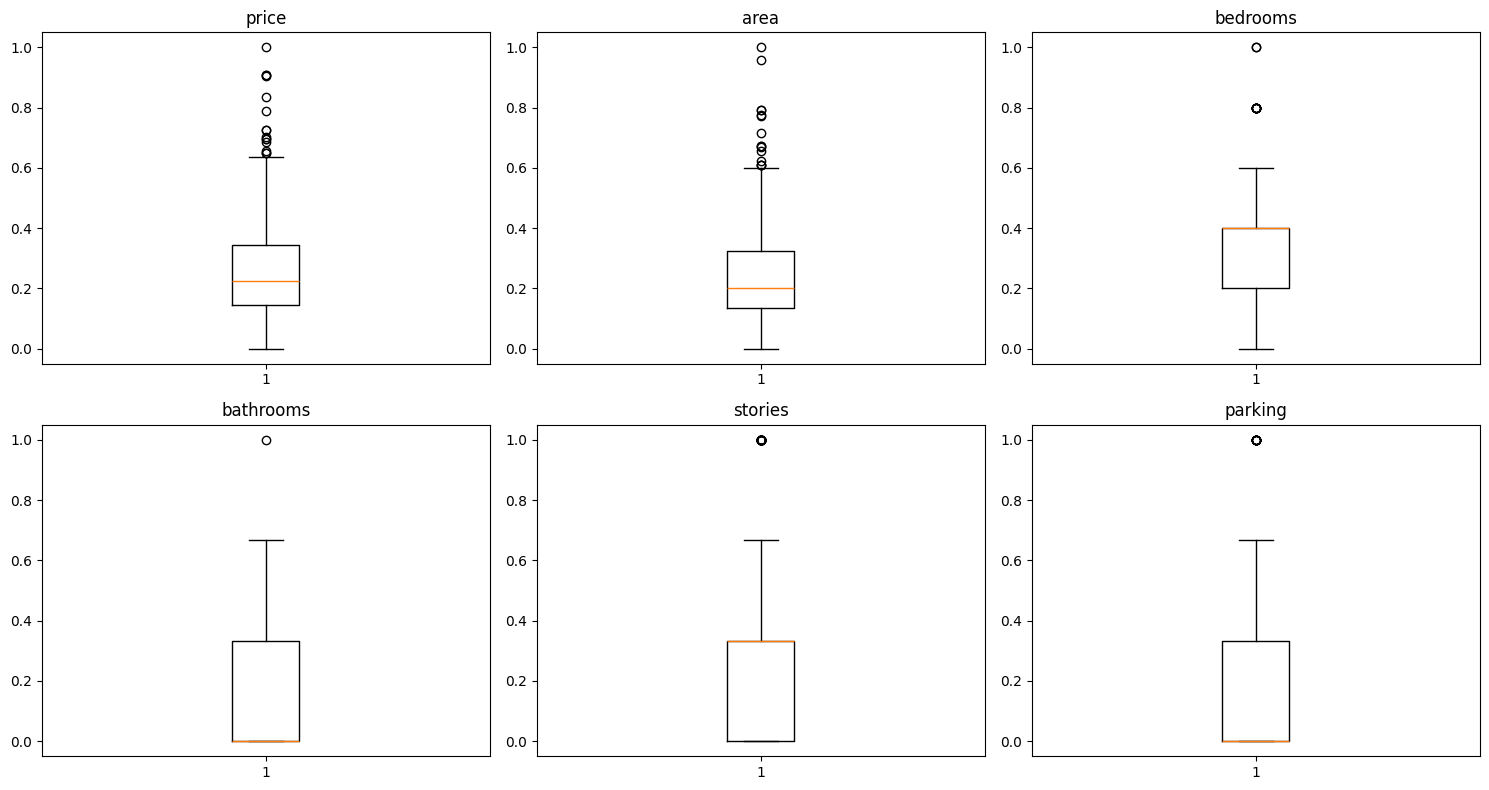

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [14]:
df_limpio = df.copy()

for col in columnas_numericas:
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & 
                          (df_limpio[col] <= limite_superior)]

print(f"Filas originales: {df.shape[0]}")
print(f"Filas después de eliminar outliers: {df_limpio.shape[0]}")
print(f"Outliers eliminados: {df.shape[0] - df_limpio.shape[0]}")

Filas originales: 545
Filas después de eliminar outliers: 365
Outliers eliminados: 180


In [15]:
df_limpio = df_limpio.copy()

# Ratio de precio por área
df_limpio['precio_por_area'] = df_limpio['price'] / df_limpio['area']

# Total de habitaciones
df_limpio['total_habitaciones'] = df_limpio['bedrooms'] + df_limpio['bathrooms']

# Índice de lujo (suma de comodidades)
df_limpio['indice_lujo'] = (df_limpio['mainroad'] + df_limpio['guestroom'] + 
                            df_limpio['basement'] + df_limpio['airconditioning'] + 
                            df_limpio['prefarea'])

print(df_limpio[['precio_por_area', 'total_habitaciones', 'indice_lujo']].head())

    precio_por_area  total_habitaciones  indice_lujo
15         2.128527                 0.6            2
20         3.302690                 0.4            2
22         1.357173                 0.4            4
27         1.159484                 0.4            1
40         1.574675                 0.4            4


In [16]:
df_limpio.to_csv("C:/Users/pc/repaso_ciencia/repaso-ciencia/data/02_intermediate/housing_limpio.csv", 
                 index=False)

print("✅ Dataset guardado correctamente!")
print(f"Filas: {df_limpio.shape[0]}")
print(f"Columnas: {df_limpio.shape[1]}")

✅ Dataset guardado correctamente!
Filas: 365
Columnas: 18
